
# Learning the Van der Pol oscillator with ResNet and Neural ODE models

- data are generated from the true Van der Pol oscillator,
- models are trained to learn the dynamics from trajectory data,
- compare a **ResNet baseline** with two **fixed-step Neural ODE models**:
  - Euler NODE
  - RK4 NODE

The purpose is to study how continuous-depth models behave on a nonlinear dynamical system that is more demanding than the damped oscillator.

## Why Van der Pol?
The Van der Pol oscillator is a natural next step after the damped oscillator because:
- it is still low-dimensional and easy to visualize,
- it is genuinely nonlinear,
- increasing the parameter $\mu$ makes the dynamics sharper and more numerically challenging.

So this notebook is a good bridge between a simple non-stiff learning problem and later discussion of stiffness.


In [1]:

import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader



## Reproducibility and CPU settings


In [2]:

# Keep PyTorch CPU execution predictable and avoid aggressive threading.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("device:", device)


device: cpu



## Experiment parameters

Recommended values:
- `MU = 1.0` for a mild nonlinear regime,
- `MU = 3.0` or `MU = 5.0` for a more interesting learning problem,
- larger values are possible, but training becomes noticeably harder.


In [3]:

# ----------------------------
# User-adjustable parameters
# ----------------------------
MU = 3.0
T0, T1 = 0.0, 10.0
N_TIME = 51
T_EVAL = np.linspace(T0, T1, N_TIME)
DT = float(T_EVAL[1] - T_EVAL[0])

N_TRAIN = 256
N_VAL = 64
N_TEST = 64

INIT_LOW = np.array([-2.5, -2.5])
INIT_HIGH = np.array([2.5, 2.5])

BATCH_SIZE = 32
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-6

HIDDEN_DIM = 64
RESNET_BLOCKS = N_TIME - 1     # one residual step per time interval
NODE_HIDDEN_DIM = 64

RESULTS_DIR = Path("../results/learning") / f"van_der_pol_mu{str(MU).replace('.', 'p')}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DT =", DT)


DT = 0.2



## True dynamical system and data generation

We generate synthetic trajectory data from the true Van der Pol oscillator
\[
\dot x = y,\qquad \dot y = \mu(1-x^2)y - x.
\]

Each sample consists of:
- an initial condition \(z_0 = (x_0, y_0)\),
- the full trajectory sampled on the grid `T_EVAL`.


In [4]:

def van_der_pol(t, z, mu=MU):
    x, y = z
    dx = y
    dy = mu * (1.0 - x**2) * y - x
    return np.array([dx, dy], dtype=np.float64)

def solve_true_trajectory(z0, t_eval=T_EVAL, mu=MU):
    sol = solve_ivp(
        fun=lambda t, z: van_der_pol(t, z, mu=mu),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=np.asarray(z0, dtype=np.float64),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(f"Trajectory generation failed: {sol.message}")
    # shape: (time, state_dim)
    return sol.y.T.astype(np.float32)

def sample_initial_conditions(n, low=INIT_LOW, high=INIT_HIGH):
    return np.random.uniform(low=low, high=high, size=(n, 2)).astype(np.float32)

def make_dataset(n_samples):
    z0s = sample_initial_conditions(n_samples)
    trajectories = np.stack([solve_true_trajectory(z0) for z0 in z0s], axis=0)
    return z0s, trajectories

train_z0, train_traj = make_dataset(N_TRAIN)
val_z0, val_traj = make_dataset(N_VAL)
test_z0, test_traj = make_dataset(N_TEST)

print("train:", train_z0.shape, train_traj.shape)
print("val:  ", val_z0.shape, val_traj.shape)
print("test: ", test_z0.shape, test_traj.shape)


train: (256, 2) (256, 51, 2)
val:   (64, 2) (64, 51, 2)
test:  (64, 2) (64, 51, 2)


## Visualize a few ground-truth trajectories

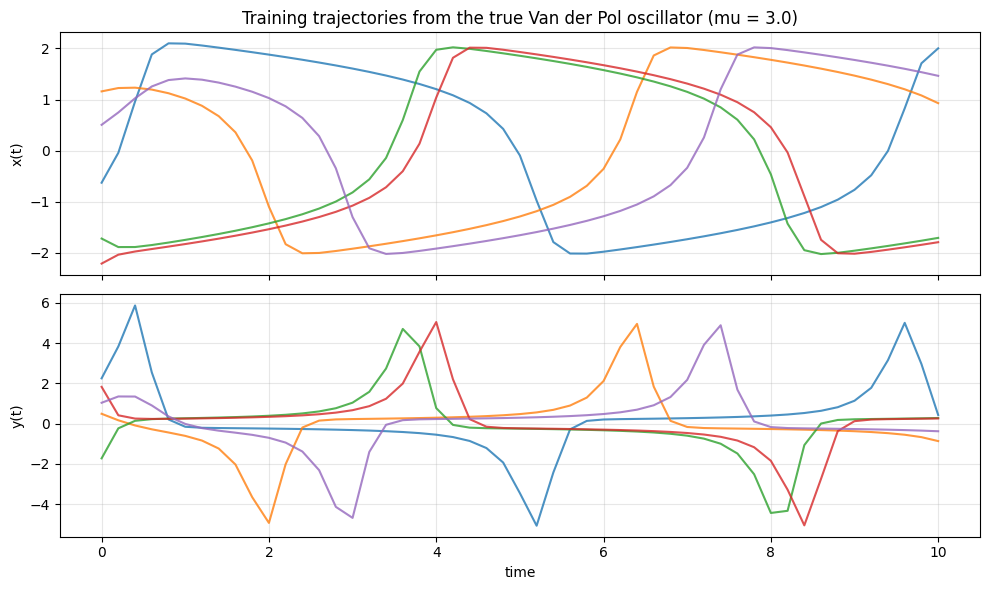

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i in range(min(5, N_TRAIN)):
    axes[0].plot(T_EVAL, train_traj[i, :, 0], alpha=0.8)
    axes[1].plot(T_EVAL, train_traj[i, :, 1], alpha=0.8)

axes[0].set_title(f"Training trajectories from the true Van der Pol oscillator (mu = {MU})")
axes[0].set_ylabel("x(t)")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("time")
axes[1].set_ylabel("y(t)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


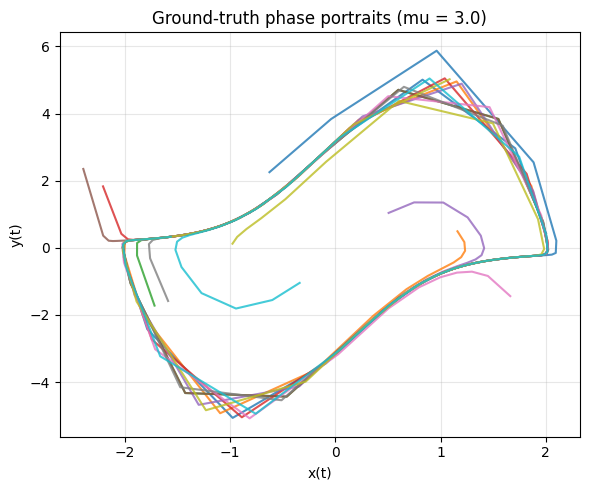

In [6]:

plt.figure(figsize=(6, 5))
for i in range(min(10, N_TRAIN)):
    plt.plot(train_traj[i, :, 0], train_traj[i, :, 1], alpha=0.8)
plt.title(f"Ground-truth phase portraits (mu = {MU})")
plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Data loaders

In [7]:

train_ds = TensorDataset(torch.from_numpy(train_z0), torch.from_numpy(train_traj))
val_ds = TensorDataset(torch.from_numpy(val_z0), torch.from_numpy(val_traj))
test_ds = TensorDataset(torch.from_numpy(test_z0), torch.from_numpy(test_traj))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)



## Models

All models take an initial condition \(z_0 \in \mathbb{R}^2\) and predict the full trajectory on the fixed grid `T_EVAL`.

### ResNet baseline
A discrete-depth model with untied residual blocks:
\[
z_{k+1} = z_k + F_k(z_k).
\]

### Neural ODE models
A learned vector field
\[
\dot z(t) = f_\theta(z(t)),
\]
integrated with a fixed-step numerical method:
- Euler,
- RK4.

This gives a fair, controlled comparison between discrete and continuous-depth perspectives.


In [8]:

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=2, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return z + DT * self.f(z)


class ResNetTrajectoryModel(nn.Module):
    def __init__(self, num_blocks=RESNET_BLOCKS, state_dim=2, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([
            ResidualBlock(state_dim=state_dim, hidden_dim=hidden_dim)
            for _ in range(num_blocks)
        ])

    def forward(self, z0):
        zs = [z0]
        z = z0
        for block in self.blocks:
            z = block(z)
            zs.append(z)
        return torch.stack(zs, dim=1)  # (batch, time, state)


class VectorField(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=NODE_HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return self.f(z)


class FixedStepNODE(nn.Module):
    def __init__(self, method="euler", state_dim=2, hidden_dim=NODE_HIDDEN_DIM):
        super().__init__()
        self.method = method.lower()
        self.vf = VectorField(state_dim=state_dim, hidden_dim=hidden_dim)

    def step_euler(self, z, dt):
        return z + dt * self.vf(z)

    def step_rk4(self, z, dt):
        k1 = self.vf(z)
        k2 = self.vf(z + 0.5 * dt * k1)
        k3 = self.vf(z + 0.5 * dt * k2)
        k4 = self.vf(z + dt * k3)
        return z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def forward(self, z0):
        zs = [z0]
        z = z0
        for _ in range(N_TIME - 1):
            if self.method == "euler":
                z = self.step_euler(z, DT)
            elif self.method == "rk4":
                z = self.step_rk4(z, DT)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            zs.append(z)
        return torch.stack(zs, dim=1)


## Utility functions

In [9]:

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def mse_loss(pred, target):
    return torch.mean((pred - target)**2)

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0
    preds_all = []
    targets_all = []

    for z0, traj in loader:
        z0 = z0.to(device)
        traj = traj.to(device)
        pred = model(z0)
        loss = mse_loss(pred, traj)

        batch_size = z0.shape[0]
        total_loss += loss.item() * batch_size
        total_n += batch_size

        preds_all.append(pred.cpu())
        targets_all.append(traj.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()
    return total_loss / total_n, preds_all, targets_all

def relative_l2_error(pred, target):
    return np.linalg.norm(pred - target) / np.linalg.norm(target)

def final_state_rmse(pred, target):
    diff = pred[:, -1, :] - target[:, -1, :]
    return np.sqrt(np.mean(diff**2))

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }

    best_state = None
    best_val = float("inf")

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_n = 0

        for z0, traj in train_loader:
            z0 = z0.to(device)
            traj = traj.to(device)

            optimizer.zero_grad()
            pred = model(z0)
            loss = mse_loss(pred, traj)
            loss.backward()
            optimizer.step()

            batch_size = z0.shape[0]
            running_loss += loss.item() * batch_size
            total_n += batch_size

        train_loss = running_loss / total_n
        val_loss, _, _ = evaluate_model(model, val_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 25 == 0 or epoch == 1:
            print(f"epoch {epoch:4d} | train {train_loss:.6f} | val {val_loss:.6f}")

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), elapsed


## Train the models

In [10]:

models = {
    "resnet": ResNetTrajectoryModel(),
    "node_euler": FixedStepNODE(method="euler"),
    "node_rk4": FixedStepNODE(method="rk4"),
}

summaries = []
histories = {}
trained_models = {}
test_predictions = {}

for name, model in models.items():
    print("=" * 80)
    print(f"Training model: {name}")
    print("parameter count:", count_parameters(model))

    trained_model, history_df, train_time = train_model(model, train_loader, val_loader)
    trained_models[name] = trained_model
    histories[name] = history_df

    train_loss, train_pred, train_true = evaluate_model(trained_model, train_loader)
    val_loss, val_pred, val_true = evaluate_model(trained_model, val_loader)
    test_loss, test_pred, test_true = evaluate_model(trained_model, test_loader)
    test_predictions[name] = test_pred

    rel_err = relative_l2_error(test_pred, test_true)
    final_rmse = final_state_rmse(test_pred, test_true)

    summaries.append({
        "model": name,
        "parameters": count_parameters(trained_model),
        "train_time_sec": train_time,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "test_rel_l2_err": rel_err,
        "test_final_state_rmse": final_rmse,
    })

summary_df = pd.DataFrame(summaries).sort_values("test_loss").reset_index(drop=True)
summary_df


Training model: resnet
parameter count: 224100
epoch    1 | train 2.663800 | val 2.184317
epoch   25 | train 1.481114 | val 1.475932
epoch   50 | train 0.858208 | val 0.892935
epoch   75 | train 0.615462 | val 0.685422
epoch  100 | train 0.597146 | val 0.695145
epoch  125 | train 0.445360 | val 0.546822
epoch  150 | train 0.559111 | val 0.573144
epoch  175 | train 0.347045 | val 0.466158
epoch  200 | train 0.324211 | val 0.439088
Training model: node_euler
parameter count: 4482
epoch    1 | train 3.763628 | val 2.396048
epoch   25 | train 1.495702 | val 1.437686
epoch   50 | train 1.091974 | val 1.118245
epoch   75 | train 0.862545 | val 0.916833
epoch  100 | train 0.770939 | val 0.807117
epoch  125 | train 0.673788 | val 0.671871
epoch  150 | train 0.455790 | val 0.504330
epoch  175 | train 0.410624 | val 0.476506
epoch  200 | train 0.301889 | val 0.341118
Training model: node_rk4
parameter count: 4482
epoch    1 | train 4.929416 | val 2.534128
epoch   25 | train 1.529017 | val 1.4480

,model,parameters,train_time_sec,train_loss,val_loss,test_loss,test_rel_l2_err,test_final_state_rmse
0,node_euler,4482,6.154382,0.292538,0.341118,0.291838,0.355568,0.677914
1,resnet,224100,11.060236,0.319421,0.430251,0.363963,0.397082,0.371415
2,node_rk4,4482,24.986305,0.566383,0.599371,0.549635,0.487965,0.873224


## Save tables

In [12]:

summary_path = RESULTS_DIR / "model_summary.csv"
summary_df.to_csv(summary_path, index=False)

for name, history_df in histories.items():
    history_path = RESULTS_DIR / f"{name}_history.csv"
    history_df.to_csv(history_path, index=False)


## Training and validation loss curves

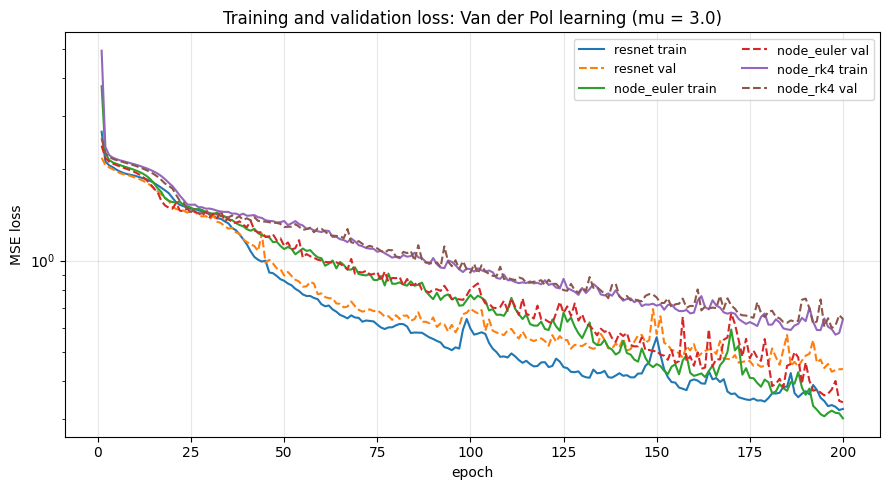

In [13]:

plt.figure(figsize=(9, 5))
for name, history_df in histories.items():
    plt.plot(history_df["epoch"], history_df["train_loss"], label=f"{name} train")
    plt.plot(history_df["epoch"], history_df["val_loss"], linestyle="--", label=f"{name} val")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title(f"Training and validation loss: Van der Pol learning (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

path = RESULTS_DIR / "loss_curves.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Compare predicted trajectories on a few test samples

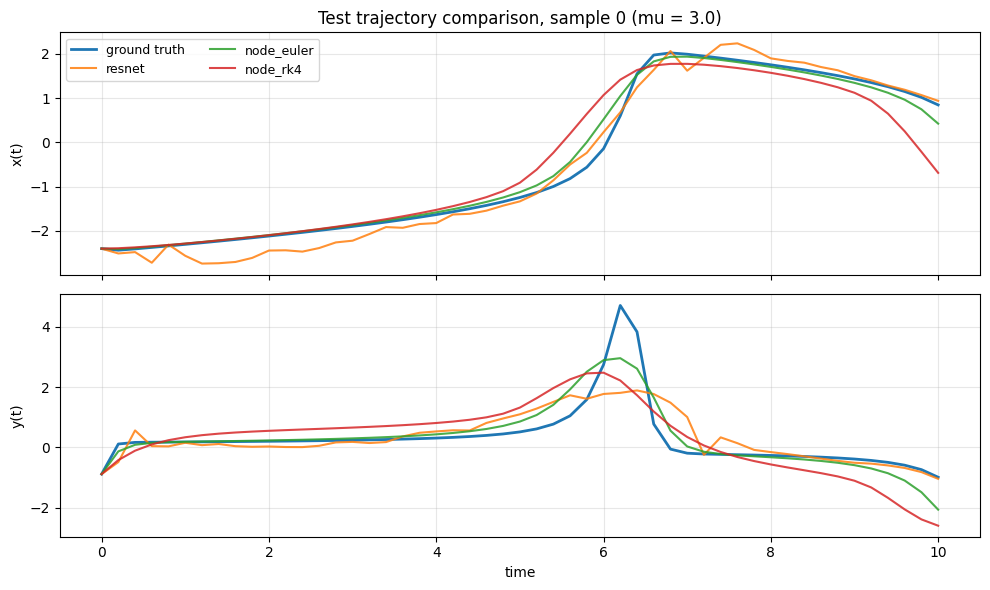

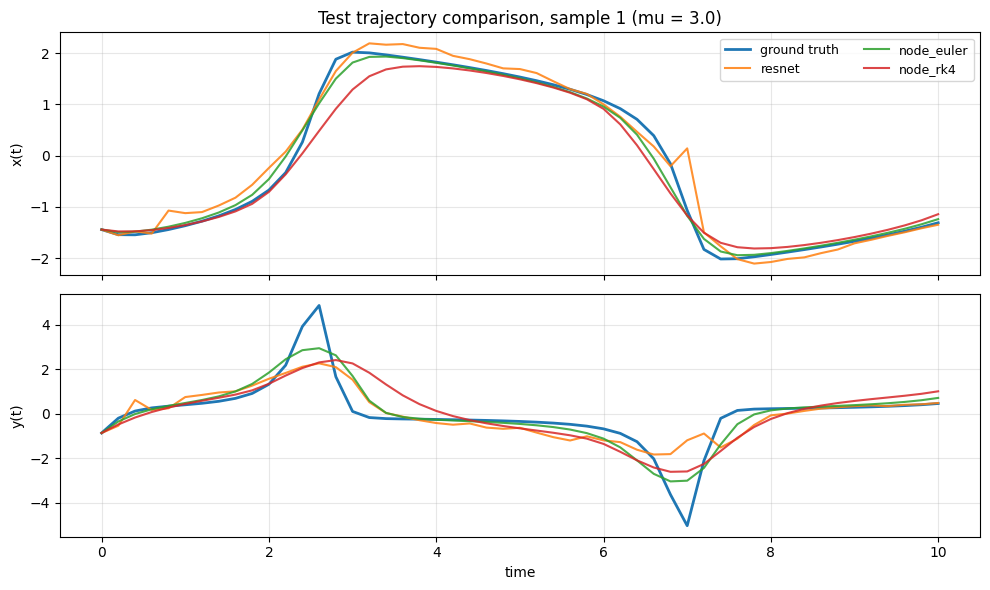

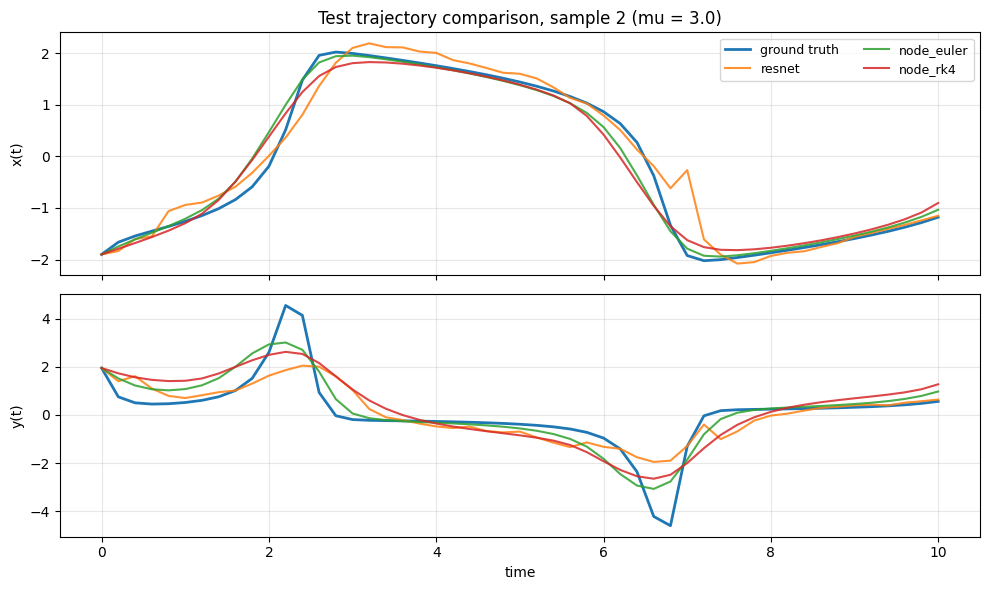

In [14]:

sample_indices = [0, 1, 2]

for idx in sample_indices:
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    true_traj = test_traj[idx]

    axes[0].plot(T_EVAL, true_traj[:, 0], linewidth=2, label="ground truth")
    axes[1].plot(T_EVAL, true_traj[:, 1], linewidth=2, label="ground truth")

    for name, pred in test_predictions.items():
        axes[0].plot(T_EVAL, pred[idx, :, 0], label=name, alpha=0.85)
        axes[1].plot(T_EVAL, pred[idx, :, 1], label=name, alpha=0.85)

    axes[0].set_title(f"Test trajectory comparison, sample {idx} (mu = {MU})")
    axes[0].set_ylabel("x(t)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(ncol=2, fontsize=9)

    axes[1].set_xlabel("time")
    axes[1].set_ylabel("y(t)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = RESULTS_DIR / f"trajectory_comparison_sample_{idx}.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


## Phase portrait comparison on a test sample

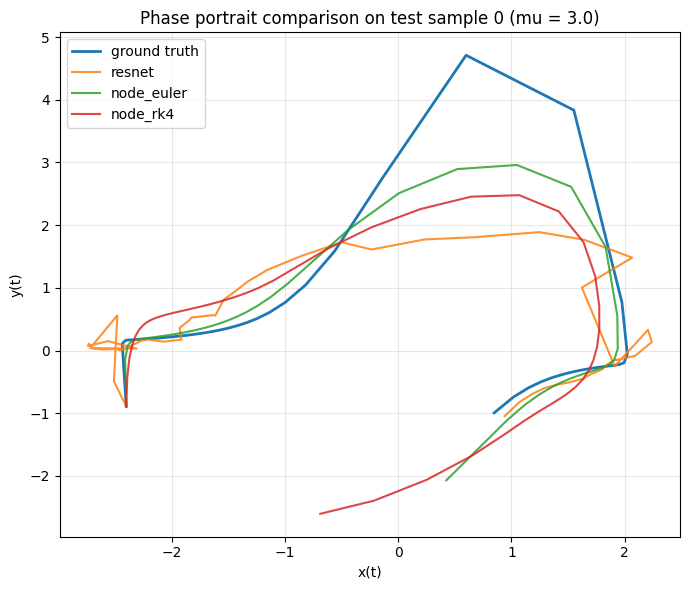

In [15]:

idx = 0
true_traj = test_traj[idx]

plt.figure(figsize=(7, 6))
plt.plot(true_traj[:, 0], true_traj[:, 1], linewidth=2, label="ground truth")

for name, pred in test_predictions.items():
    plt.plot(pred[idx, :, 0], pred[idx, :, 1], label=name, alpha=0.85)

plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.title(f"Phase portrait comparison on test sample {idx} (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

path = RESULTS_DIR / "phase_portrait_test_sample.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Parameter count versus test loss

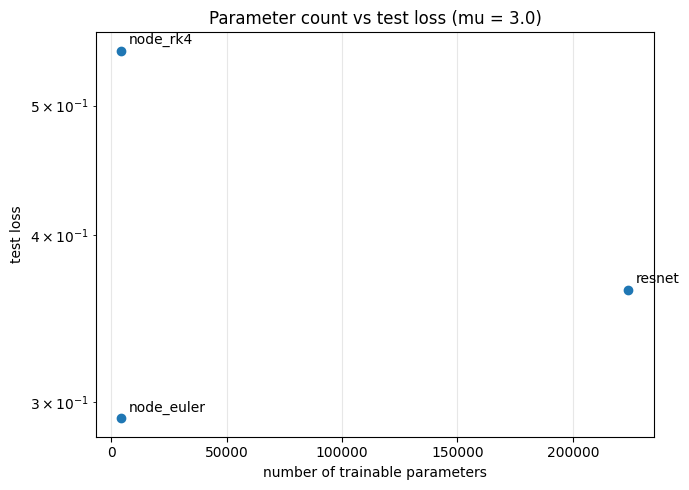

In [16]:

plt.figure(figsize=(7, 5))
plt.scatter(summary_df["parameters"], summary_df["test_loss"])

for _, row in summary_df.iterrows():
    plt.annotate(row["model"], (row["parameters"], row["test_loss"]), xytext=(5, 5), textcoords="offset points")

plt.yscale("log")
plt.xlabel("number of trainable parameters")
plt.ylabel("test loss")
plt.title(f"Parameter count vs test loss (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "parameters_vs_test_loss.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()



## save raw test predictions

In [17]:

np.save(RESULTS_DIR / "test_t_eval.npy", T_EVAL)
np.save(RESULTS_DIR / "test_ground_truth.npy", test_traj)

for name, pred in test_predictions.items():
    np.save(RESULTS_DIR / f"{name}_test_predictions.npy", pred)

print("Saved raw arrays.")


Saved raw arrays.
